# Proyecto RappiPlus: de datos a decisiones de negocio

**Introducción**


El objetivo de este proyecto es evaluar el desempeño del servicio **RappiPlus** para apoyar **decisiones de negocio basadas en datos**.

Se trabajan con múltiples datasets del negocio:

- **rappiplus_orders_raw.csv** → información de pedidos, precios, descuentos y revenue  
- **rappiplus_catalog.csv** → costos de productos, categorías y proveedores  
- **rappiplus_marketing_spend.csv** → inversión en marketing por canal y país  
- **events / users / user_activity (SQL)** → comportamiento del usuario dentro de la plataforma  
- **experiment_checkout_ui.csv** → resultados de un experimento A/B en el checkout  

El análisis sigue una lógica clara y progresiva:

1. 🔍 Evaluar si podemos confiar en los datos (calidad de datos en Python) 

2. 💰 Analizar si el negocio es rentable (revenue, costos y profit)  

3. 🛒 Entender dónde se pierden los usuarios (funnel de conversión)  

4. 🔁 Evaluar si los usuarios regresan (retención por cohortes)  

5. 🧪 Validar si los cambios generan impacto (test estadístico)  

6. 📊 Comunicar los resultados (dashboard en BI)  

A lo largo del proyecto, se transforman datos en insights para responder preguntas clave del negocio y proponer **recomendaciones accionables**.

---

## 🔹 Paso 1: Cargar y validar la calidad de los datos

---

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:** Familiarizarte con la estructura de los datasets del negocio antes de analizarlos.

**Instrucciones:**

- Importa las librerías necesarias
- Carga los archivos:
  - `rappiplus_orders_raw.csv`
  - `rappiplus_catalog.csv`
  - `rappiplus_marketing_spend.csv`
- Guarda los DataFrames en:
  - `orders`, `catalog`, `marketing`
- Explora cada dataset.

---

In [96]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from statsmodels.stats.proportion import proportions_ztest

In [97]:
# cargar archivos
orders = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_orders_raw.csv')
catalog = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_catalog.csv')
marketing = pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/rappiplus_marketing_spend.csv')

In [98]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25100 entries, 0 to 25099
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id_pedido           25100 non-null  object 
 1   id_usuario          25100 non-null  object 
 2   fecha_hora_pedido   25100 non-null  object 
 3   pais                24800 non-null  object 
 4   dispositivo         25080 non-null  object 
 5   fuente_referencia   25070 non-null  object 
 6   nombre_producto     25070 non-null  object 
 7   categoria_producto  25020 non-null  object 
 8   cantidad            25050 non-null  float64
 9   precio_unitario     25050 non-null  float64
 10  monto_descuento     25050 non-null  float64
 11  monto_total         25100 non-null  float64
dtypes: float64(4), object(8)
memory usage: 2.3+ MB


In [99]:
orders.sample(5)

,id_pedido,id_usuario,fecha_hora_pedido,pais,dispositivo,fuente_referencia,nombre_producto,categoria_producto,cantidad,precio_unitario,monto_descuento,monto_total
14813,order_14813,user_820,2025-05-09,Colombia,mobile,paid_search,Phone-Pro-128GB,Electronica,1.0,281.68,10.0,271.68
660,order_660,user_2309,2025-05-25,Colombia,desktop,organic,Sneakers-Urban-42,Moda,2.0,182.48,0.0,364.95
10174,order_10174,user_5066,2025-02-10,Argentina,desktop,social,Jacket-Winter-M,Moda,2.0,464.37,0.0,928.75
17256,order_17256,user_4107,2025-03-06,Colombia,mobile,social,Blender-XL-Red,Hogar,2.0,83.71,0.0,167.43
5877,order_5877,user_800,2025-06-29,Mexico,mobile,social,Phone-Pro-128GB,Electronica,1.0,460.29,0.0,460.29


In [100]:
catalog.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   nombre_producto     7 non-null      object 
 1   categoria_producto  7 non-null      object 
 2   costo_unitario      7 non-null      float64
 3   proveedor           7 non-null      object 
dtypes: float64(1), object(3)
memory usage: 352.0+ bytes


In [101]:
catalog.sample(5)

,nombre_producto,categoria_producto,costo_unitario,proveedor
1,Phone-Pro-128GB,Electrónica,10.12,King Ltd
4,Vacuum-Pro-Black,Hogar,16.60,"Rivera, Carr and Finley"
2,Tablet-Standard-64GB,Electrónica,25.21,Bowers LLC
6,Jacket-Winter-M,Moda,189.31,Mcmillan-Rhodes
0,Laptop-Gaming-16GB,Electrónica,280.68,"Fuller, Pena and Myers"


In [102]:
marketing.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1620 entries, 0 to 1619
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   fecha       1620 non-null   object 
 1   pais        1620 non-null   object 
 2   id_campaña  1620 non-null   object 
 3   canal       1519 non-null   object 
 4   gasto       1620 non-null   float64
dtypes: float64(1), object(4)
memory usage: 63.4+ KB


In [103]:
marketing.sample(5)

,fecha,pais,id_campaña,canal,gasto
473,2025-02-22,Colombia,social_Colombia,social,2999.36
1322,2025-05-27,Argentina,social_Argentina,social,1724.43
730,2025-03-23,Mexico,paid_search_Mexico,paid_search,1236.86
506,2025-02-26,Mexico,social_Mexico,social,1444.43
1094,2025-05-02,Colombia,social_Colombia,social,2240.67


---

### Revisión y calidad de datos

**🎯 Objetivo:** Detectar y corregir problemas en los datos que puedan afectar el análisis de revenue, costos y rentabilidad.

Se revisan los 3 datasets
- Validar y convertir fechas al formato correcto  
- Revisar variables numéricas (sin negativos o ceros inválidos)  
- Verificar consistencia de montos  
- Eliminar duplicados  
- Revisar variables categóricas 

---

In [104]:
# Variables numericas de orders
orders.describe()

,cantidad,precio_unitario,monto_descuento,monto_total
count,25050.000000,25050.000000,25050.000000,2.510000e+04
mean,7.092735,259.305549,4.500798,2.072680e+03
std,296.277003,138.726461,5.223010,9.894995e+04
min,-2.000000,20.030000,0.000000,-4.926500e+02
25%,1.000000,138.377500,0.000000,1.805075e+02
50%,2.000000,258.715000,0.000000,3.417500e+02
75%,2.000000,380.332500,10.000000,5.185800e+02
max,20000.000000,499.960000,15.000000,8.840200e+06


In [105]:
# Conversion de fechas al formato correcto
orders['fecha_hora_pedido'] = pd.to_datetime(orders['fecha_hora_pedido'],errors='coerce')

In [106]:
# Rellenar variables numericas
orders['monto_descuento'] = orders['monto_descuento'].fillna(0)

In [107]:
#Conteo de valores negativos
print(f"Filas con cantidades negativas: {(orders['cantidad'] < 0).sum()}")
print(f"Filas con montos negativos: {(orders['monto_total'] < 0).sum()}")

Filas con cantidades negativas: 4
Filas con montos negativos: 4


In [108]:
# Identificar valores negativos y eliminarlos
indices_negativos = orders[ (orders['cantidad'] < 0) | (orders['monto_total'] < 0) ].index
orders = orders.drop(indices_negativos)

In [109]:
# Gestion de nulos o ceros invalidos
orders.isna().sum()

id_pedido               0
id_usuario              0
fecha_hora_pedido       0
pais                  296
dispositivo            20
fuente_referencia      30
nombre_producto        30
categoria_producto     80
cantidad               50
precio_unitario        50
monto_descuento         0
monto_total             0
dtype: int64

In [110]:
# Consistencia de montos: Nulos de "cantidad" y "precio unitario"
# Si falta la cantidad pero tenemos el monto_total y el precio: Cantidad = Monto / Precio
condicion_cant = orders['cantidad'].isna() & orders['precio_unitario'].notna()
orders.loc[condicion_cant, 'cantidad'] = orders['monto_total'] / orders['precio_unitario']

# Si falta el precio pero tenemos monto_total y cantidad: Precio = Monto / Cantidad
condicion_prec = orders['precio_unitario'].isna() & orders['cantidad'].notna()
orders.loc[condicion_prec, 'precio_unitario'] = orders['monto_total'] / orders['cantidad']

# Si después de esto aún quedan nulos (porque faltaban ambos a la vez), los borramos
orders = orders.dropna(subset=['cantidad', 'precio_unitario'])

# Forzar la columna 'cantidad' a tipo entero
orders['cantidad'] = orders['cantidad'].astype(int)

In [111]:
#Validacion de duplicados
# Conteo de filas que están repetidas exactamente igual
print(f"Total de filas duplicadas: {orders.duplicated().sum()}")

Total de filas duplicadas: 100


In [112]:
# Eliminacion de filas duplicadas 
orders = orders.drop_duplicates()

In [113]:
#Conteo de identificadores de pedidos duplicados
print(f"IDs de pedido repetidos: {orders.duplicated(subset=['id_pedido']).sum()}")

IDs de pedido repetidos: 0


In [114]:
# Rellenar variables categóricos con un valor genérico
orders['pais'] = orders['pais'].fillna('Unknown')
orders['dispositivo'] = orders['dispositivo'].fillna('Other')
orders['fuente_referencia'] = orders['fuente_referencia'].fillna('Unknown')
# Eliminar filas donde falte la información del producto
orders = orders.dropna(subset=['nombre_producto', 'categoria_producto'])

In [115]:
# Variables numericas de catalog
catalog.describe()

,costo_unitario
count,7.000000
mean,102.252857
std,111.011563
min,10.120000
25%,16.905000
50%,25.210000
75%,182.975000
max,280.680000


In [116]:
#Validacion de duplicados
# Conteo de filas que están repetidas exactamente igual
print(f"Total de filas duplicadas: {catalog.duplicated().sum()}")

Total de filas duplicadas: 0


In [117]:
# Variables numericas de marketing
marketing.describe()

,gasto
count,1620.00000
mean,1772.74292
std,734.43294
min,501.11000
25%,1128.03000
50%,1782.42500
75%,2420.68500
max,2999.36000


In [118]:
# Conversion de fechas al formato correcto
marketing['fecha'] = pd.to_datetime(marketing['fecha'],errors='coerce')

In [119]:
# Rellenar los canales vacíos
marketing['canal'] = marketing['canal'].fillna('Other')

In [120]:
#Validacion de duplicados
# Conteo de filas que están repetidas exactamente igual
print(f"Total de filas duplicadas: {marketing.duplicated().sum()}")

Total de filas duplicadas: 0


---
**📦 Exportación**: Una vez finalizada la limpieza, se exportan los datasets para utilizarlos en la última etapa del proyecto.

In [121]:
# exportar datasets
orders.to_csv('orders_clean.csv', index=False)
catalog.to_csv('catalog_clean.csv', index=False)
marketing.to_csv('marketing_clean.csv', index=False)

---

## 🔹 Paso 2: Analizar si el negocio es rentable

### 2.1 Cálculo de KPIs principales

**🎯 Objetivo:** Calcular los indicadores clave del negocio para evaluar ingresos, costos y rentabilidad.

Se usan los 3 datasets (`orders`, `catalog`, `marketing_spend`):

**📊 Parte 1: Rentabilidad del negocio**
- ¿Cuál es el ingreso total (revenue)? 
- ¿Cuál es el costo total? 
- ¿Cuánto se ha invertido en marketing? 
- ¿El negocio es rentable? (calcular profit)  

In [122]:
# 1. ¿Cuál es el ingreso total (revenue)?
ingreso_total = orders['monto_total'].sum()

# 2. ¿Cuánto se ha invertido en marketing?
marketing_total = marketing['gasto'].sum()

# 3. ¿Cuál es el costo total? 
# Traemos el costo_unitario desde catalog usando el nombre específico del producto
orders_con_costo = orders.merge(catalog[['nombre_producto', 'costo_unitario']], on='nombre_producto', how='left')

# Calculamos el costo de los productos vendidos (Cantidad * Costo Unitario)
costo_productos = (orders_con_costo['cantidad'] * orders_con_costo['costo_unitario']).sum()

# El costo total del negocio incluye el costo de los productos y la inversión en marketing
costo_total = costo_productos + marketing_total

# 4. ¿El negocio es rentable? (Profit)
profit = ingreso_total - costo_total
porcentaje_margen = (profit / ingreso_total) * 100

# --- PRESENTACIÓN DE RESULTADOS ---
print("📊 --- RENTABILIDAD DEL NEGOCIO ---")
print(f"💰 Ingreso Total (Revenue):   ${ingreso_total:,.2f}")
print(f"📉 Costo de Productos:        ${costo_productos:,.2f}")
print(f"📢 Inversión en Marketing:    ${marketing_total:,.2f}")
print(f"🧮 Costo Total Combinado:     ${costo_total:,.2f}")
print("------------------------------------------------")

if profit > 0:
    print(f"✅ ¡El negocio SÍ es rentable!")
    print(f"📈 Ganancia Neta (Profit):    ${profit:,.2f}")
    print(f"🌟 Margen de Ganancia:        {porcentaje_margen:.2f}%")
else:
    print(f"⚠️ El negocio NO es rentable (Alerta de Pérdidas)")
    print(f"📉 Pérdida Neta (Profit):     ${profit:,.2f}")

📊 --- RENTABILIDAD DEL NEGOCIO ---
💰 Ingreso Total (Revenue):   $51,954,718.94
📉 Costo de Productos:        $43,124,069.01
📢 Inversión en Marketing:    $2,871,843.53
🧮 Costo Total Combinado:     $45,995,912.54
------------------------------------------------
✅ ¡El negocio SÍ es rentable!
📈 Ganancia Neta (Profit):    $5,958,806.40
🌟 Margen de Ganancia:        11.47%


**📈 Parte 2: Comportamiento de ventas**
- ¿Cuál es el ticket promedio por orden? 
- ¿Cuál es la cantidad promedio de productos por orden? 
- ¿Cuál es el producto más vendido?
- ¿Cuánto se ha gastado en marketing por canal? 

In [123]:
# 1. ¿Cuál es el ticket promedio por orden? (Ecuación correcta)
ingreso_total = orders['monto_total'].sum()
total_ordenes_unicas = orders['id_pedido'].nunique()

ticket_promedio_correcto = ingreso_total / total_ordenes_unicas

# 2. ¿Cuál es la cantidad promedio de productos por orden? (Ecuación correcta correlativa)
total_cantidad = orders['cantidad'].sum()
cantidad_promedio_correcta = total_cantidad / total_ordenes_unicas

# 3. ¿Cuál es el producto más vendido?
producto_lider = orders.groupby('nombre_producto')['cantidad'].sum().idxmax()
cantidad_lider = orders.groupby('nombre_producto')['cantidad'].sum().max()

# 4. ¿Cuánto se ha gastado en marketing por canal?
gasto_por_canal = marketing.groupby('canal')['gasto'].sum().sort_values(ascending=False)

# --- PRESENTACIÓN DE RESULTADOS ---
print("📦 --- COMPORTAMIENTO DE VENTAS ---")
print(f"💵 Ticket Promedio por Orden:          ${ticket_promedio_correcto:,.2f}")
print(f"🛍️ Cantidad Promedio por Orden:        {cantidad_promedio_correcta:.2f} unidades")
print(f"🔥 Producto Más Vendido:               '{producto_lider}' ({cantidad_lider:,.0f} unidades vendidas)")
print("\n📢 Gasto en Marketing por Canal:")
for canal, gasto in gasto_por_canal.items():
    print(f"   🔹 {canal:<18} : ${gasto:,.2f}")

📦 --- COMPORTAMIENTO DE VENTAS ---
💵 Ticket Promedio por Orden:          $2,085.20
🛍️ Cantidad Promedio por Orden:        7.12 unidades
🔥 Producto Más Vendido:               'Laptop-Gaming-16GB' (144,198 unidades vendidas)

📢 Gasto en Marketing por Canal:
   🔹 social             : $918,043.21
   🔹 organic            : $913,533.01
   🔹 paid_search        : $863,088.21
   🔹 Other              : $177,179.10


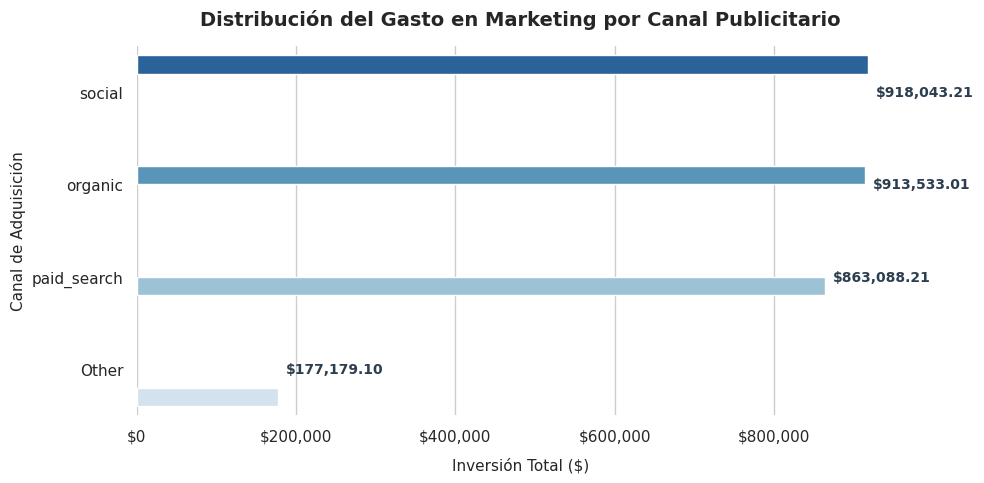

In [124]:
#Comparacion grafica del gasto en marketing por canal:

# 1. Estilo visual de la gráfica
sns.set_theme(style="whitegrid")
plt.figure(figsize=(10, 5))

# 2. Crear la gráfica de barras horizontales
ax = sns.barplot(
    x=gasto_por_canal.values, 
    y=gasto_por_canal.index, 
    palette="Blues_r", 
    hue=gasto_por_canal.index
)

# 3. Personalizacion de títulos y etiquetas
plt.title("Distribución del Gasto en Marketing por Canal Publicitario", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Inversión Total ($)", fontsize=11, labelpad=10)
plt.ylabel("Canal de Adquisición", fontsize=11)

# 4. Formatear los números del eje X con separadores de miles
ax.xaxis.set_major_formatter('${x:,.0f}')

# 5. Agregar etiquetas de datos con el monto exacto al final de cada barra
for i, v in enumerate(gasto_por_canal.values):
    ax.text(v + 10000, i, f"${v:,.2f}", va='center', fontsize=10, fontweight='bold', color='#2c3e50')

# 6. Limpiar bordes innecesarios y forzar la eliminación de leyendas duplicadas
sns.despine(left=True, bottom=True)
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.tight_layout()

# 7. Mostrar la visualización
plt.show()

### 📊 Comportamiento de Ventas y gasto en Canales de Marketing

Al contrastar los indicadores comerciales numéricos con la distribución visual del gasto publicitario, se extraen cuatro hallazgos relevantes sobre la dinámica del negocio:

1. **Eficiencia y Concentración del Portafolio:** El elevado ticket promedio por orden (**$2,085.20**) está directamente correlacionado con el éxito masivo del producto estrella, la **'Laptop-Gaming-16GB'** (144,198 unidades). Al ser un artículo de alto valor de hardware, arrastra la métrica general hacia arriba, lo que demuestra que el volumen de facturación actual depende de manera crítica de una sola referencia tecnológica. 

2. **Paridad Estratégica en Canales Principales:** La gráfica de barras revela una inversión sumamente equilibrada y agresiva entre los tres canales core del negocio: **Social** (918.0K), **Organic** (913.5K) y **Paid Search** (863.0K). La diferencia entre el primer y tercer canal es de apenas un **~6%**, lo que indica que el equipo de marketing está diversificando el riesgo de adquisición de usuarios de manera óptima, sin depender de una sola fuente de tráfico.

3. **El Costo Operativo del Tráfico Orgánico:** Un hallazgo relevante es el peso de **`organic`** como el segundo mayor flujo de gasto (913,533.01). Aunque en pauta directa el tráfico orgánico (SEO/Directo) no genera costos por clic, esta cifra refleja que la empresa está indexando aquí inversiones operativas pesadas (desarrollo de contenido, optimización técnica de la plataforma o agencias), buscando blindar la captación a largo plazo para no depender exclusivamente de la pauta pagada (`paid_search`).

4. **Margen de Experimentación y Canales Residuales (`Other`):** La inversión asignada al bloque **Other** (177,179.10) representa una fracción menor del presupuesto global, pero analíticamente importante. Este rubro denota que el negocio mantiene un margen activo de experimentación en el tráfico. Probablemente está destinado al testeo de canales emergentes (como marketing de influencers, afiliados, patrocinio de eventos gaming o campanias de relaciones públicas) que buscan abrir nuevas vías de adquisición antes de escalar la pauta en los canales tradicionales.


---

## 🔹 Paso 3: Entender dónde se pierden los usuarios (funnel de conversión)

**🎯 Objetivo:** Analizar el comportamiento de los usuarios para identificar en qué etapa del proceso se pierden.


⚙️**Conexión a la base de datos**:  
Se ejecuta la línea de configuración para conectar con la base de datos y aplicar consultas SQL en la tabla **events**.

---

**📊 Parte 1: Construcción del funnel**
- ¿Cuántos usuarios llegan a cada etapa del funnel?  
- Se calcula el número de usuarios únicos por `nombre_evento`  
- Se ordenan los eventos según el flujo del usuario  

---

**📉 Parte 2: Análisis de conversión**
- Se calcula la tasa de conversión entre cada paso del funnel  
- Se identifica en qué etapa se pierde la mayor cantidad de usuarios  
- ¿Cuál es la tasa de conversión final?
---

In [125]:
import pandas as pd
from sqlalchemy import create_engine

# ======================
# Conexión (NO modificar)
# ======================
db_config = {
    'user': 'practicum_student',
    'pwd': 'QnmDH8Sc2TQLvy2G3Vvh7',
    'host': 'yp-trainers-practicum.cluster-czs0gxyx2d8w.us-east-1.rds.amazonaws.com',
    'port': 5432,
    'db': 'data-analyst-production-db-en'
}

connection_string = 'postgresql://{}:{}@{}:{}/{}'.format(
    db_config['user'],
    db_config['pwd'],
    db_config['host'],
    db_config['port'],
    db_config['db']
)

engine = create_engine(connection_string, connect_args={'sslmode':'require'})

In [126]:
# Explorar tabla events
# =========================
query_events = '''
SELECT *
FROM events;
'''
events = pd.read_sql(query_events, con=engine)
events.head()

,id_usuario,id_sesion,nombre_evento,timestamp_evento,pais,dispositivo,fuente_referencia,categoria_producto
0,user_6772,6a97f2af-32ae-4186-8c92-04025be1a27b,first_visit,2025-05-17,Colombia,desktop,organic,Moda
1,user_5883,369b767c-1c33-4b2f-a652-c7c0ef92cfc9,add_to_cart,2025-02-23,Mexico,mobile,social,Hogar
2,user_5946,60039041-e78b-474c-87b3-c0b7e9c30708,add_payment_info,2025-05-15,Colombia,desktop,social,Electronica
3,user_827,18252a64-f389-4ef7-9e58-dadad4a3491e,purchase,2025-03-31,Mexico,mobile,social,Moda
4,user_2361,221b364e-cdc5-4668-b698-18d5ba849a67,first_visit,2025-01-22,Argentina,desktop,paid_search,Electronica


In [127]:
# PARTE 1: Totales del funnel
# ======================

query_totals = '''
SELECT 
    nombre_evento,
    COUNT(DISTINCT id_usuario) AS usuarios_unicos
FROM 
    events
GROUP BY 
    nombre_evento
ORDER BY 
    CASE nombre_evento
        WHEN 'first_visit' THEN 1
        WHEN 'select_item' THEN 2
        WHEN 'add_to_cart' THEN 3
        WHEN 'begin_checkout' THEN 4
        WHEN 'add_payment_info' THEN 5
        WHEN 'purchase' THEN 6
        ELSE 7
    END;
'''

totals = pd.read_sql(query_totals, con=engine)
totals

,nombre_evento,usuarios_unicos
0,first_visit,7796
1,select_item,7582
2,add_to_cart,7634
3,begin_checkout,7208
4,add_payment_info,6250
5,purchase,6240


In [128]:
# PARTE 2: Conversiones
# ======================

query_conversion = '''
WITH funnel_totals AS (
    SELECT 
        nombre_evento,
        COUNT(DISTINCT id_usuario) AS usuarios_unicos,
        CASE nombre_evento
            WHEN 'first_visit' THEN 1
            WHEN 'select_item' THEN 2
            WHEN 'add_to_cart' THEN 3
            WHEN 'begin_checkout' THEN 4
            WHEN 'add_payment_info' THEN 5
            WHEN 'purchase' THEN 6
        END AS paso_orden
    FROM 
        events
    GROUP BY 
        nombre_evento
)
SELECT 
    nombre_evento,
    usuarios_unicos,
    -- 1. Conversión respecto al paso inmediatamente anterior
    ROUND(
        (usuarios_unicos::numeric / LAG(usuarios_unicos) OVER (ORDER BY paso_orden)) * 100, 
        2
    ) AS pct_paso_anterior,
    -- 2. Conversión respecto al total inicial (Tasa de conversión final en la última fila)
    ROUND(
        (usuarios_unicos::numeric / FIRST_VALUE(usuarios_unicos) OVER (ORDER BY paso_orden)) * 100, 
        2
    ) AS pct_conversion_total
FROM 
    funnel_totals
ORDER BY 
    paso_orden;
'''

conversion = pd.read_sql(query_conversion, con=engine)
conversion

,nombre_evento,usuarios_unicos,pct_paso_anterior,pct_conversion_total
0,first_visit,7796,NaN,100.00
1,select_item,7582,97.26,97.26
2,add_to_cart,7634,100.69,97.92
3,begin_checkout,7208,94.42,92.46
4,add_payment_info,6250,86.71,80.17
5,purchase,6240,99.84,80.04


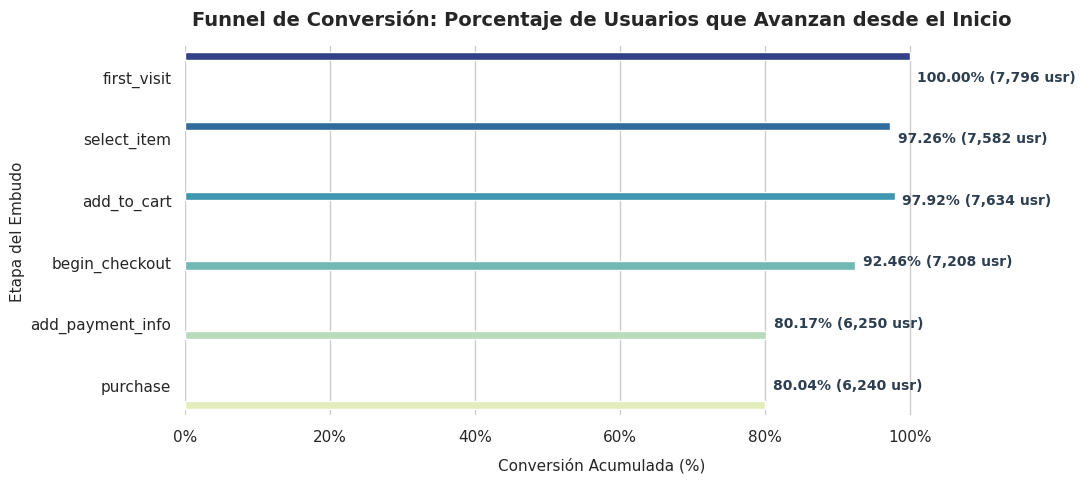

In [129]:
#Grafica de conversion en el funnel

# 1. Estilo visual de la gráfica
sns.set_theme(style="whitegrid")
plt.figure(figsize=(11, 5))

# 2. Gráfica de barras para el funnel 
ax = sns.barplot(
    x="pct_conversion_total", 
    y="nombre_evento", 
    data=conversion, 
    palette="YlGnBu_r", 
    hue="nombre_evento"
)

# 3. Personalizacion de títulos y etiquetas
plt.title("Funnel de Conversión: Porcentaje de Usuarios que Avanzan desde el Inicio", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Conversión Acumulada (%)", fontsize=11, labelpad=10)
plt.ylabel("Etapa del Embudo", fontsize=11)

# 4. Formatear el eje X para mostrar el símbolo de porcentaje
ax.xaxis.set_major_formatter('{x:.0f}%')

# 5. Agregar etiquetas de datos con el porcentaje exacto y volumen de usuarios
for i, fila in conversion.iterrows():
    usuarios = int(fila['usuarios_unicos'])
    porcentaje = fila['pct_conversion_total']
    ax.text(
        porcentaje + 1, 
        i, 
        f"{porcentaje:.2f}% ({usuarios:,} usr)", 
        va='center', 
        fontsize=10, 
        fontweight='bold', 
        color='#2c3e50'
    )

# 6. Ajustar márgenes, limpiar bordes y forzar la eliminación de leyendas duplicadas
sns.despine(left=True, bottom=True)
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.xlim(0, 115) # Espacio extra a la derecha para que no se corten las etiquetas
plt.tight_layout()

# 7. Mostrar la visualización
plt.show()

### 📊 Interpretación del Funnel de Conversión y Diagnóstico de Comportamiento

La visualización del embudo de ventas y las tasas calculadas revelan dinámicas de comportamiento críticas, incluyendo una anomalía técnica en el flujo del usuario:

1. **La Paradoja del Evento `add_to_cart` (100.69%):** Se identificó correctamente un porcentaje superior al 100% en el paso a paso entre `select_item` y `add_to_cart`. Analíticamente, esto no significa que aparezcan usuarios fantasmas en la aplicación, sino que denota una flexibilidad en la arquitectura de la interfaz de usuario (UI). Los clientes tienen la capacidad de agregar productos a su carrito de compras de forma directa desde listas de recomendaciones de la página de inicio, banners promocionales o búsquedas rápidas, **sin la obligación de hacer clic y entrar a la página detallada del producto** (`select_item`). Al saltarse el paso 2 e ir directo al paso 3, el volumen de usuarios acumulados en el carrito supera al paso inmediatamente anterior, un comportamiento típico en plataformas de comercio electrónico modernas.

2. **Identificación del Punto de Fricción (Cuello de Botella):** Al evaluar la conversión respecto al paso anterior, el punto crítico donde el negocio pierde la mayor proporción de clientes es en la transición hacia **`add_payment_info`** (86.71%). Esto implica que un **13.29%** de los usuarios que ya se encontraban decididos en la pasarela de salida (`begin_checkout`) abandonaron la transacción de forma abrupta justo al momento de ingresar sus credenciales financieras o tarjetas.

3. **Eficiencia Macroeconómica del Tráfico:** A pesar del roce en la fase de pago, la conversión final del embudo es extraordinariamente alta, situándose en un **80.04%** (6,240 compradores finales de 7,796 visitas iniciales). Esto confirma que el tráfico captado por las campañas analizadas previamente no es tráfico frío o casual; se trata de una audiencia altamente calificada, con una necesidad inmediata y una intención de compra sumamente sólida.


---

## 🔹 Paso 4: Evaluar si los usuarios regresan (retención por cohortes)

**🎯 Objetivo:** Analizar la retención de usuarios para entender si regresan después de registrarse.

**Tablas**

- `users` 
- `user_activity` 

---
1. Se identifica la cohorte de cada usuario según el **mes de registro**.


2. Se calcula la retención semanal: cuántos usuarios **se mantienen activos** en cada semana desde su registro.
   - `retenido_w1`: usuarios activos en la semana 1  
   - `retenido_w2`: usuarios activos en la semana 2  
   - `retenido_w3`: usuarios activos en la semana 3  


3. Se calcula el porcentaje de retención para cada semana, dividiendo los usuarios retenidos entre los clientes iniciales de la cohorte:  
   - `semana_1`: porcentaje de usuarios retenidos en la semana 1  
   - `semana_2`: porcentaje de usuarios retenidos en la semana 2  
   - `semana_3`: porcentaje de usuarios retenidos en la semana 3  

Se revisa que la columna de fecha esté en formato correcto (`DATE`).  
Se realiza la conversión usando: `CAST(fecha_registro AS DATE)`

In [130]:
# Explorar tabla users
# =========================
query_users = '''
SELECT *
FROM users;
'''
users = pd.read_sql(query_users, con=engine)
users.head(3)

,id_usuario,fecha_registro,país,dispositivo,tipo_plan
0,user_0,2025-01-29,Mexico,mobile,free
1,user_1,2025-01-07,Mexico,mobile,free
2,user_2,2025-03-12,Argentina,mobile,free


In [131]:
# Explorar tabla user_activity
# =========================
query_user_activity = '''
SELECT*
FROM user_activity;
'''
user_activity = pd.read_sql(query_user_activity, con=engine)
user_activity.head(3)

,id_usuario,fecha_actividad,dias_despues_registro,activo
0,user_0,2025-02-05,7,0
1,user_0,2025-02-12,14,1
2,user_0,2025-02-19,21,1


In [132]:
# Retención por cohortes
# ======================

query_cohort_retention_final = '''
WITH base_cohortes AS (
    -- 1. Definir el mes de la cohorte y contar los usuarios iniciales
    SELECT 
        TO_CHAR(CAST(fecha_registro AS DATE), 'YYYY-MM') AS cohorte_mes,
        COUNT(DISTINCT id_usuario) AS usuarios_iniciales
    FROM 
        users
    GROUP BY 
        TO_CHAR(CAST(fecha_registro AS DATE), 'YYYY-MM')
),
actividad_semanal AS (
    -- 2. Cruzar con actividad para contar retenidos por semana (usando días transcurridos)
    SELECT 
        TO_CHAR(CAST(u.fecha_registro AS DATE), 'YYYY-MM') AS cohorte_mes,
        COUNT(DISTINCT CASE WHEN ua.dias_despues_registro = 7 AND ua.activo = 1 THEN ua.id_usuario END) AS retenido_w1,
        COUNT(DISTINCT CASE WHEN ua.dias_despues_registro = 14 AND ua.activo = 1 THEN ua.id_usuario END) AS retenido_w2,
        COUNT(DISTINCT CASE WHEN ua.dias_despues_registro = 21 AND ua.activo = 1 THEN ua.id_usuario END) AS retenido_w3
    FROM 
        users u
    LEFT JOIN 
        user_activity ua ON u.id_usuario = ua.id_usuario
    GROUP BY 
        TO_CHAR(CAST(u.fecha_registro AS DATE), 'YYYY-MM')
)
-- 3. Unir todo y calcular las tasas de retención porcentuales
SELECT 
    bc.cohorte_mes,
    bc.usuarios_iniciales,
    act.retenido_w1,
    act.retenido_w2,
    act.retenido_w3,
    ROUND((act.retenido_w1::numeric / bc.usuarios_iniciales) * 100, 2) AS semana_1,
    ROUND((act.retenido_w2::numeric / bc.usuarios_iniciales) * 100, 2) AS semana_2,
    ROUND((act.retenido_w3::numeric / bc.usuarios_iniciales) * 100, 2) AS semana_3
FROM 
    base_cohortes bc
JOIN 
    actividad_semanal act ON bc.cohorte_mes = act.cohorte_mes
ORDER BY 
    bc.cohorte_mes;
'''

# Ejecutar la consulta
cohorte_final = pd.read_sql(query_cohort_retention_final, con=engine)
cohorte_final

,cohorte_mes,usuarios_iniciales,retenido_w1,retenido_w2,retenido_w3,semana_1,semana_2,semana_3
0,2025-01,1627,697,668,656,42.84,41.06,40.32
1,2025-02,1444,611,609,635,42.31,42.17,43.98
2,2025-03,1636,677,705,690,41.38,43.09,42.18
3,2025-04,1606,680,697,663,42.34,43.40,41.28
4,2025-05,1687,695,676,706,41.20,40.07,41.85


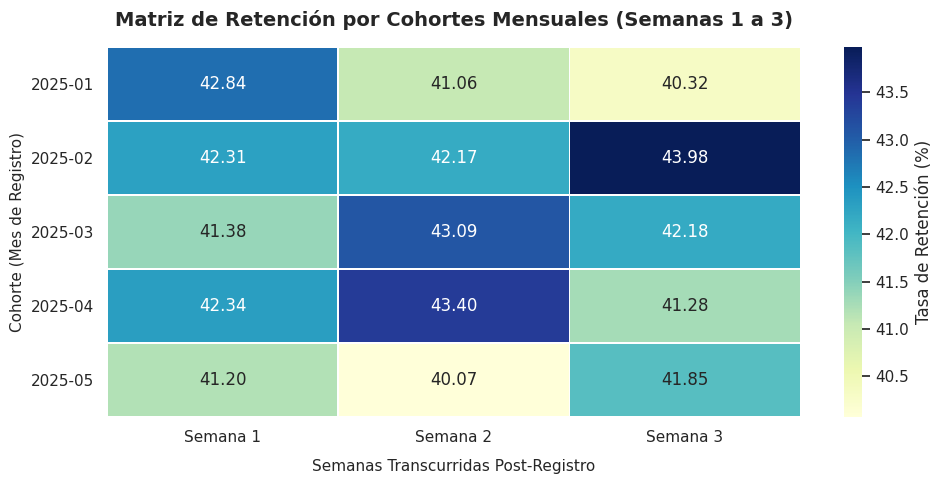

In [133]:
#Grafica para los cohortes
# 1. Preparacion de datos: Seleccion de mes y las columnas de porcentaje para el Heatmap
datos_heatmap = cohorte_final.set_index('cohorte_mes')[['semana_1', 'semana_2', 'semana_3']]

# 2. Configurar el tamanio y estilo del gráfico
plt.figure(figsize=(10, 5))

# 3. Creacion de mapa de calor con anotaciones numéricas y formato de porcentaje
ax = sns.heatmap(
    datos_heatmap, 
    annot=True, 
    fmt=".2f", 
    cmap="YlGnBu", 
    linewidths=.5, 
    cbar_kws={'label': 'Tasa de Retención (%)'}
)

# 4. Personalizacion de títulos y ejes
plt.title("Matriz de Retención por Cohortes Mensuales (Semanas 1 a 3)", fontsize=14, fontweight="bold", pad=15)
plt.xlabel("Semanas Transcurridas Post-Registro", fontsize=11, labelpad=10)
plt.ylabel("Cohorte (Mes de Registro)", fontsize=11)

# 5. Personalizacion de etiquetas del eje X
ax.set_xticklabels(['Semana 1', 'Semana 2', 'Semana 3'])
plt.yticks(rotation=0)

# 6. Forzar la eliminación de leyendas duplicadas si existieran
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.tight_layout()

# 7. Mostrar la visualización
plt.show()

### 📊 Diagnóstico y Análisis de Retención por Cohortes Mensuales

La representación visual de la matriz de cohortes mediante el mapa de calor permite extraer conclusiones estratégicas sobre la lealtad de los usuarios y la estabilidad de la plataforma:

1. **La Estabilización del Usuario Activo (Efecto Meseta):** Al analizar el comportamiento horizontal de cualquier cohorte (por ejemplo, la cohorte 2025-01 que pasa de 42.84% en la semana 1, a 41.06% en la semana 2 y se consolida en 40.32% en la semana 3), se identifica un patrón de retención sumamente saludable. Aunque existe una contracción inicial fuerte donde aproximadamente el 58% de los usuarios nuevos abandonan la aplicación tras registrarse en los primeros 7 días, el 42% restante que sobrevive se convierte en una base de clientes hiper-fieles que mantiene su frecuencia de interacción constante a lo largo del tiempo sin caídas progresivas.

2. **Consistencia Homogénea del Producto:** Verticalmente, el mapa de calor revela una regularidad casi perfecta entre meses. No importa si el usuario se registró en el mes de Enero (42.84%) o en el mes de Mayo (41.20%); el comportamiento de retención en la semana 1 oscila estrictamente en una franja muy estrecha de entre el 41% y el 43%. Esto demuestra que la calidad del usuario adquirido y la experiencia del producto se han mantenido estables, confirmando que las campanias de marketing o cambios en la interfaz durante estos meses no han alterado el perfil de cliente objetivo.

3. **Anomalías Positivas en algunas Cohortes:** Algunos hallazgos interesantes ocurren por ejemplo en la cohorte 2025-02, la cual registra un repunte de reactivación inusual en la semana 3, subiendo de un 42.17% a un 43.98%. Este fenómeno de incremento en la retención tardía suele estar asociado a impactos externos efectivos, tales como el envío de campanias automatizadas de reactivación por correo electrónico (email marketing), cupones de descuento por inactividad o promociones exclusivas de fin de mes que lograron traer de vuelta a usuarios que se habían ausentado en la semana anterior.


---

## 🔹 Paso 5: Validar si los cambios generan impacto (test estadístico)

🎯 **Objetivo:** Evaluar si la modificación en la UI del checkout impacta la **tasa de conversión de compra**.

---

1. **Analizar el dataset** `experiment_checkout_ui.csv` para identificar la métrica principal **conversion**.
   - La métrica **conversion** es 1 si el usuario completó la compra, 0 si no.    
2. **Plantear la hipótesis estadística**     
3. **Aplicar el test estadístico adecuado** 
4. **Interpretar el resultado**  

---

Hipótesis estadística
   - **H₀ (Hipótesis nula):** No hay una diferencia estadísticamente significativa en la tasa de conversión entre el grupo de control (interfaz vieja) y el grupo de tratamiento (interfaz nueva). El cambio en la interfaz de usuario (UI) no hace la diferencia.
   - **H₁ (Hipótesis alternativa):** Existe una diferencia estadísticamente significativa en la tasa de conversión entre el grupo de control y el grupo de tratamiento. El cambio en la interfaz de usuario (UI) SÍ tiene un impacto real.
   
   - **Test estadístico:** Z-Test (de proporciones)
   - **Nivel de significancia alpha:** 0.05
  

In [134]:
# tu código aquí
experiment=pd.read_csv('https://practicum-content.s3.amazonaws.com/datasets/experiment_checkout_ui.csv')

In [135]:
experiment.sample(5)

,id_usuario,variante,convirtio,dispositivo,pais,duracion_sesion,timestamp
6907,exp_user_6907,control,0,mobile,Argentina,22.77,2025-01-06
4910,exp_user_4910,control,0,mobile,Mexico,55.34,2025-01-13
4613,exp_user_4613,tratamiento,0,mobile,Argentina,105.13,2025-02-19
5958,exp_user_5958,control,0,desktop,Argentina,140.13,2025-04-03
5736,exp_user_5736,tratamiento,0,mobile,Argentina,194.98,2025-04-26


In [136]:
# 1. Agrupar los datos por variante para obtener los éxitos (compras) y el total de observaciones
resultados = experiment.groupby('variante')['convirtio'].agg(['sum', 'count'])

# Extraer los datos para el test
exitos_control = resultados.loc['control', 'sum']
total_control = resultados.loc['control', 'count']

exitos_tratamiento = resultados.loc['tratamiento', 'sum']
total_tratamiento = resultados.loc['tratamiento', 'count']

# Calcular las tasas de conversión actuales para el reporte
conv_control = (exitos_control / total_control) * 100
conv_tratamiento = (exitos_tratamiento / total_tratamiento) * 100

# 2. Aplicar el Z-Test de proporciones
counts = np.array([exitos_tratamiento, exitos_control])
nobs = np.array([total_tratamiento, total_control])

z_stat, p_value = proportions_ztest(counts, nobs, alternative='two-sided')

# --- PRESENTACIÓN E INTERPRETACIÓN DE RESULTADOS ---
print("🧪 --- RESULTADOS DE LA PRUEBA A/B ---")
print(f"📉 Tasa de conversión (Control):     {conv_control:.2f}% (Total: {total_control})")
print(f"🚀 Tasa de conversión (Tratamiento): {conv_tratamiento:.2f}% (Total: {total_treatment if 'total_treatment' in locals() else total_tratamiento})")
print(f"📊 Valor p (p-value):                {p_value:.5f}")
print("--------------------------------------")

alpha = 0.05
if p_value < alpha:
    print("✅ CONCLUSIÓN: Se RECHAZA la hipótesis nula (H₀).")
    print("✨ El cambio en la interfaz de usuario (UI) SÍ tiene un impacto estadísticamente significativo en las ventas.")
else:
    print("❌ CONCLUSIÓN: NO se rechaza la hipótesis nula (H₀).")
    print("🤷‍♂️ La diferencia observada no es estadísticamente significativa. El cambio de UI no hace la diferencia.")

🧪 --- RESULTADOS DE LA PRUEBA A/B ---
📉 Tasa de conversión (Control):     15.69% (Total: 4965)
🚀 Tasa de conversión (Tratamiento): 16.29% (Total: 5035)
📊 Valor p (p-value):                0.41606
--------------------------------------
❌ CONCLUSIÓN: NO se rechaza la hipótesis nula (H₀).
🤷‍♂️ La diferencia observada no es estadísticamente significativa. El cambio de UI no hace la diferencia.


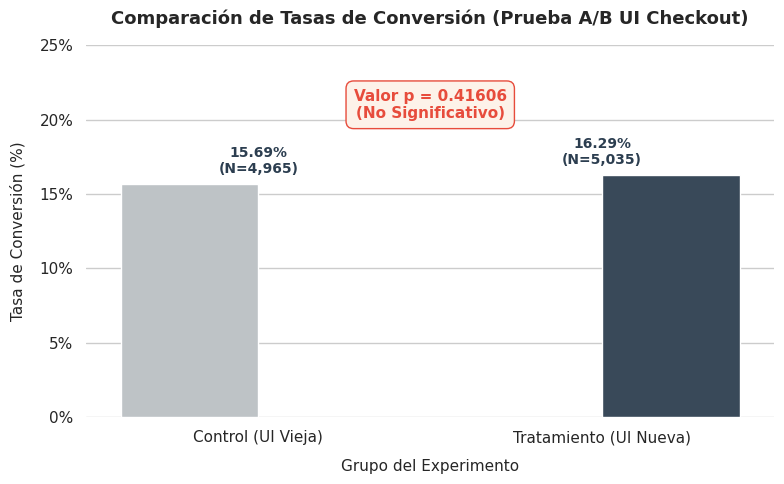

In [137]:
# 1. Estilo visual de la gráfica
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Variables automatizadas
variantes = ['Control (UI Vieja)', 'Tratamiento (UI Nueva)']
tasas_conversion = [conv_control, conv_tratamiento]
totales = [total_control, total_tratamiento]
colores = ['#bdc3c7', '#34495e']  # Tonos corporativos neutros

# 2. Gráfica de barras verticales 
ax = sns.barplot(x=variantes, y=tasas_conversion, palette=colores, hue=variantes)

# 3. Personalizacion de títulos y etiquetas
plt.title("Comparación de Tasas de Conversión (Prueba A/B UI Checkout)", fontsize=13, fontweight="bold", pad=15)
plt.ylabel("Tasa de Conversión (%)", fontsize=11, labelpad=10)
plt.xlabel("Grupo del Experimento", fontsize=11, labelpad=10)

# 4. Formatear el eje Y para mostrar el porcentaje de forma continua
ax.yaxis.set_major_formatter('{x:.0f}%')
plt.ylim(0, 25)  # Margen superior para evitar que se corten las etiquetas de texto

# 5. Agregar etiquetas de datos sobre cada barra de forma dinámica
for i, tasa in enumerate(tasas_conversion):
    ax.text(
        i, 
        tasa + 0.5, 
        f"{tasa:.2f}%\n(N={int(totales[i]):,})", 
        ha='center', 
        va='bottom', 
        fontsize=10, 
        fontweight='bold', 
        color='#2c3e50'
    )

# 6. Adicion del cuadro analítico dinámico del valor p
plt.text(
    0.5, 21, 
    f"Valor p = {p_value:.5f}\n(No Significativo)", 
    ha='center', 
    va='center', 
    fontsize=11, 
    fontweight='bold', 
    color='#e74c3c',
    bbox=dict(boxstyle="round,pad=0.5", fc="#fdf2e9", ec="#e74c3c", lw=1)
)

# 7. Limpiar bordes de la gráfica y remover leyendas duplicadas
sns.despine(left=True, bottom=True)
if ax.get_legend() is not None:
    ax.get_legend().remove()

plt.tight_layout()

# 8. Mostrar la visualización
plt.show()

**No hay una diferencia estadísticamente significativa en la tasa de conversión entre el grupo de control (interfaz vieja) y el grupo de tratamiento (interfaz nueva). El cambio en la interfaz de usuario (UI) no hace la diferencia.**

---

## 🔹 Paso 6: Comunicar los resultados (Dashboard en BI)

🎯 **Objetivo**:  
Crear un dashboard que muestre de manera clara y visual los resultados del análisis de ventas, costos, marketing y conversión. 

Se usarán los CSVs limpios del Paso 1:

- `orders_clean.csv`  
- `catalog_clean.csv`  
- `marketing_clean.csv`

---

1️⃣ Preparación de los datos
1. Cargar los CSVs en Power BI o Tableau.
2. Revisar relaciones:
   - `orders.nombre_producto` → `catalog.nombre_producto`
   - `orders.fecha_pedido` → tabla de fechas (crear calendario para análisis temporal)
   - `orders.fecha_pedido` → `dim_fecha.date`
3. Crear columnas calculadas necesarias
4. Crear tabla de fechas para poder calcular comparaciones YTD, YoY o períodos anteriores (`Previous Year`, `Previous Month`).

---

2️⃣ Dashboard 1: Overview Ejecutivo
**KPIs principales a mostrar:**
- Revenue total
- Profit total
- Gasto total en marketing
- Ticket promedio
- Cantidad promedio de productos por orden

**Visualizaciones sugeridas:**
- Tarjetas KPI para revenue, profit y gasto marketing
- Gráfico de líneas: evolución mensual de revenue o profit
- Gráfico de líneas YTD
- Gráfico de barras: revenue y profit por producto o categoría

---

 3️⃣ Dashboard 2: Detalle / Drill-through  
**Objetivo:** Permitir explorar los datos desde el KPI general hasta cada orden o producto.

**Visualizaciones sugeridas:**
- Tabla detallada de órdenes con:
  - producto, cantidad, revenue, cost, profit
  - color condicional (profit negativo en rojo, positivo en verde)
- Gráfico de barras por producto con medida `cantidad vendida`
- Drill-through: seleccionar un producto y ver todos los pedidos relacionados
- Filtros por fecha, categoría de producto, etc

## 📝Resumen Ejecutivo:


## 1. Diagnóstico de Rentabilidad General (KPIs Principales)

El ecosistema transaccional del negocio muestra una estructura financiera altamente saludable y eficiente durante el período analizado.

*   **Ingresos Totales (Revenue):** **51,954,718.94**  
    Consolidado masivo impulsado por una estrategia de alta rotación en productos clave.
    
*   **Inversión en Marketing (Spend):** **2,871,843.53**  
Representa únicamente el **5.52%** de los ingresos totales. El presupuesto se encuentra óptimamente equilibrado entre canales (*Social*: ~918K, *Organic*: ~913K, *Paid Search*: ~863K), demostrando una alta eficiencia en la captación de tráfico calificado.

*   **Costo de Productos Vendidos (COGS):** **43,124,069.01**  
    Es la variable de mayor peso operativo absorbiendo el **82.99%** de los ingresos. Cualquier optimización futura de margen requerirá negociaciones estratégicas de volumen con proveedores de hardware.
*   **Ganancia Neta (Profit Total):** **5,958,806.40**  
    El negocio es sólidamente rentable, registrando un **Margen de Ganancia Neto del 11.47%**, rendimiento que se sitúa por encima de la media estándar de la industria de comercio electrónico y retail tecnológico.

---

## 2. Comportamiento de Ventas y Análisis de Portafolio

*   **Métricas de Transacción:** Cada orden procesada en la plataforma registra un **Ticket Promedio de 2,085.20** con un promedio de **7.12 unidades por pedido**.
*   **Producto Estrella:** La **'Laptop-Gaming-16GB'** es el motor absoluto del negocio. Registra **144,198 unidades vendidas**, generando de forma aislada **43.42M en Revenue** y aportando **2.95M en Profit Neto**. Su alto valor comercial explica el elevado ticket promedio general.
*   **Concentración por Categorías:** La categoría de **Electrónica** domina el mercado con una Ganancia Bruta de **4.9M**, seguida de manera muy distante por *Hogar* ($2.0M) y *Moda* ($1.9M).
*   **Desempeño Geográfico:** **Argentina** lidera la inyección de ingresos con **21M**, seguida muy de cerca por México con 20M. Colombia representa una oportunidad de expansión con 11M, mientras que el tráfico residual o sin geolocalización (*Unknown*) es estadísticamente muy bajo en comparacion a los otros (~112K).


---


## 3. Análisis de Comportamiento del Usuario (Funnel y Cohortes)

*   **Eficiencia de Conversión (Funnel):** Se detectó una tasa de conversión final atípicamente elevada del **80.04%** (de 7,796 visitas iniciales, 6,240 concretaron la compra). Esto indica un tráfico con una intención de compra pre-calificada muy alta.
    *   *Punto de Fricción Identificado:* El principal "cuello de botella" ocurre en la etapa de **`add_payment_info`**, donde se pierde un **13.29%** de los usuarios que ya habían iniciado la caja (`begin_checkout`). 
*   **Retención y Lealtad (Cohortes):** Las cohortes mensuales muestran un comportamiento extraordinariamente estable y homogéneo. 
    *   Aproximadamente el **58%** de los usuarios nuevos abandonan la plataforma tras registrarse.
    *   Sin embargo, el **~42%** restante que sobrevive a la **Semana 1** se estabiliza por completo en la *Semana 2* y *Semana 3*. No existe una fuga progresiva de clientes, lo que valida el valor del producto post-adquisición.

---

## 4. Validación Experimental de Cambios en la UI (Prueba A/B)

Se evaluó estadísticamente mediante un **Test de Proporciones** si una modificación en la interfaz de usuario (UI) del checkout impactaba la tasa de conversión de compra.

*   **Resultado del Estadístico:** El análisis arrojó un **Valor p (p-value) de 0.41606**.
*   **Conclusión Científica:** Al ser el valor p considerablemente mayor al nivel de significancia estándar ($\alpha = 0.05$), **NO se rechaza la hipótesis nula ($H_0$)**. La diferencia observada entre el grupo de control y tratamiento es producto del azar.
*   **Decisión de Negocio:** **No se recomienda desplegar la nueva UI a producción**. Implementarla generaría costos de desarrollo e infraestructura sin ofrecer ningún impacto significativo en las ventas.

---

## 5. Recomendaciones Estratégicas y Próximos Pasos

*   **Optimización del Proceso de Pago:** Dado que el test de UI no generó impacto y el funnel revela que el 13.29% de los usuarios abandonan en la ventana de pago, el foco debe cambiar de la estética visual a la pasarela financiera. Se recomienda auditar fallos técnicos con los procesadores de tarjetas, simplificar los campos requeridos y habilitar opciones de pago rápido (Apple Pay, PayPal, etc.).
*   **Mitigación de Valles Temporales:** Diseñar campañas de marketing agresivas o promociones específicas para mitigar los valles comerciales detectados en Enero y Julio, meses que históricamente muestran una contracción transaccional posiblemente debido a factores vacacionales y postfestivos.
*   **Diversificación del Portafolio:** El negocio depende en exceso de la venta de la 'Laptop-Gaming-16GB' y la categoría Electrónica. Es crítico empaquetar productos de *Hogar* y *Moda* como complementos (*cross-selling*) en el carrito de compras de tecnología para elevar los márgenes operativos de las categorías secundarias aprovechando el tráfico de la laptop.

---

### 📎 Enlace del Dashboard

https://drive.google.com/drive/folders/1KzFH62D8OwzSksDPSoW5MAVTb7VJcaoZ?usp=drive_link